# v2 — Step 03: Preprocessing

## Purpose
Normalise, log-transform, select highly variable genes (HVGs), and scale the filtered
count matrix in preparation for dimensionality reduction.

## Processing steps
1. **Verify raw counts layer** — confirm `layers['counts']` holds integer UMIs
2. **Library-size normalisation** — scale each cell to 10,000 total counts (CPM-equivalent)
3. **Log1p transformation** — compress dynamic range; makes downstream variance estimates meaningful
4. **HVG selection** — retain the 3,000 most informative genes using Seurat v3 method
5. **Save full gene set** to `adata.raw` for later marker gene visualisation
6. **Subset to HVGs** — reduces matrix size; PCA runs on HVGs only
7. **Z-score scaling** — zero mean, unit variance per gene; caps at 10 to suppress outliers

## Input
- `data/processed/v2/GSE116222_v2_qc_filtered.h5ad`

## Output
- `data/processed/v2/GSE116222_v2_preprocessed.h5ad`

In [1]:
import os
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.set_figure_params(dpi=150, facecolor='white', frameon=False)

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/homebrew/Caskroom/miniconda/base/

In [3]:
os.chdir("/Users/Vicky/vicky/UC_Single_Cell_analysis")
print("cwd:", os.getcwd())
adata = sc.read_h5ad('data/processed/v2/GSE116222_v2_qc_filtered.h5ad')
print(f"Loaded: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(f"layers: {list(adata.layers.keys())}")

cwd: /Users/Vicky/vicky/UC_Single_Cell_analysis
Loaded: 7,791 cells × 21,970 genes
layers: ['counts']


## Step 1 — Verify raw counts layer

The `layers['counts']` array must contain integer UMI values before we proceed.
This layer is required by `sc.pp.highly_variable_genes(..., flavor='seurat_v3', layer='counts')`
because the Seurat v3 mean-variance model was fitted on raw UMI counts.
Passing log-normalised values to it produces incorrect HVG rankings.

In [4]:
from scipy.sparse import issparse

counts = adata.layers['counts']
vals   = counts.data if issparse(counts) else counts.flatten()

print(f"layers['counts'] dtype        : {counts.dtype}")
print(f"layers['counts'] integer-valued: {bool(np.all(vals == np.floor(vals)))}")
print(f"layers['counts'] value range   : {int(vals.min())} – {int(vals.max())}")
print("\nVerification: PASS — raw counts confirmed")

layers['counts'] dtype        : int32
layers['counts'] integer-valued: True
layers['counts'] value range   : 1 – 11169

Verification: PASS — raw counts confirmed


## Step 2 — Library-size normalisation

Each cell is scaled so its total counts sum to 10,000 (target_sum = 1e4).
This corrects for the fact that cells differ in sequencing depth — a gene detected
in 10 counts in a 2,000-UMI cell and 50 counts in a 10,000-UMI cell has the same
relative expression after normalisation.

After this step, `.X` holds normalised (but not log-transformed) values.

In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)

# Verify normalisation
cell_sums = np.array(adata.X.sum(axis=1)).flatten()
print(f"Post-normalisation cell sum range: {cell_sums.min():.1f} – {cell_sums.max():.1f}")
print(f"(All cells should sum to 10,000)")

Post-normalisation cell sum range: 10000.0 – 10000.0
(All cells should sum to 10,000)


## Step 3 — Log1p transformation

Applies `log(x + 1)` to every value. The `+1` pseudocount prevents `log(0) = -∞` for
unexpressed genes. This transformation:
- Compresses the right tail (a few highly expressed genes no longer dominate)
- Makes the distribution approximately normal, stabilising variance for PCA
- Ensures that fold-changes are computed correctly in downstream DE analysis

In [6]:
sc.pp.log1p(adata)
print(f"Post-log1p dtype : {adata.X.dtype}")
print(f"Post-log1p .X range:")
from scipy.sparse import issparse
x_vals = adata.X.data if issparse(adata.X) else adata.X.flatten()
print(f"  min = {x_vals.min():.4f}")
print(f"  max = {x_vals.max():.4f}")

Post-log1p dtype : float32
Post-log1p .X range:
  min = 0.2750
  max = 8.7982


## Step 4 — Highly variable gene (HVG) selection

We select the 3,000 most highly variable genes using the **Seurat v3** method.
This method models the mean–variance relationship of raw UMI counts using a
negative binomial model, then selects genes whose variance exceeds expectation.

**Critical**: `layer='counts'` passes the raw integer counts to the Seurat v3 estimator.
Without this, it would incorrectly receive log-normalised values and produce wrong HVG rankings.

3,000 HVGs is a commonly used value for scRNA-seq datasets of this size and captures
the major sources of biological variation without including too many noisy genes.

In [7]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor='seurat_v3',
    layer='counts'  # raw integers required by seurat_v3
)

n_hvg = adata.var['highly_variable'].sum()
print(f"Highly variable genes selected: {n_hvg}")
print(f"Total genes in dataset        : {adata.n_vars}")
print(f"HVG fraction                  : {n_hvg / adata.n_vars * 100:.1f}%")

Highly variable genes selected: 3000
Total genes in dataset        : 21970
HVG fraction                  : 13.7%


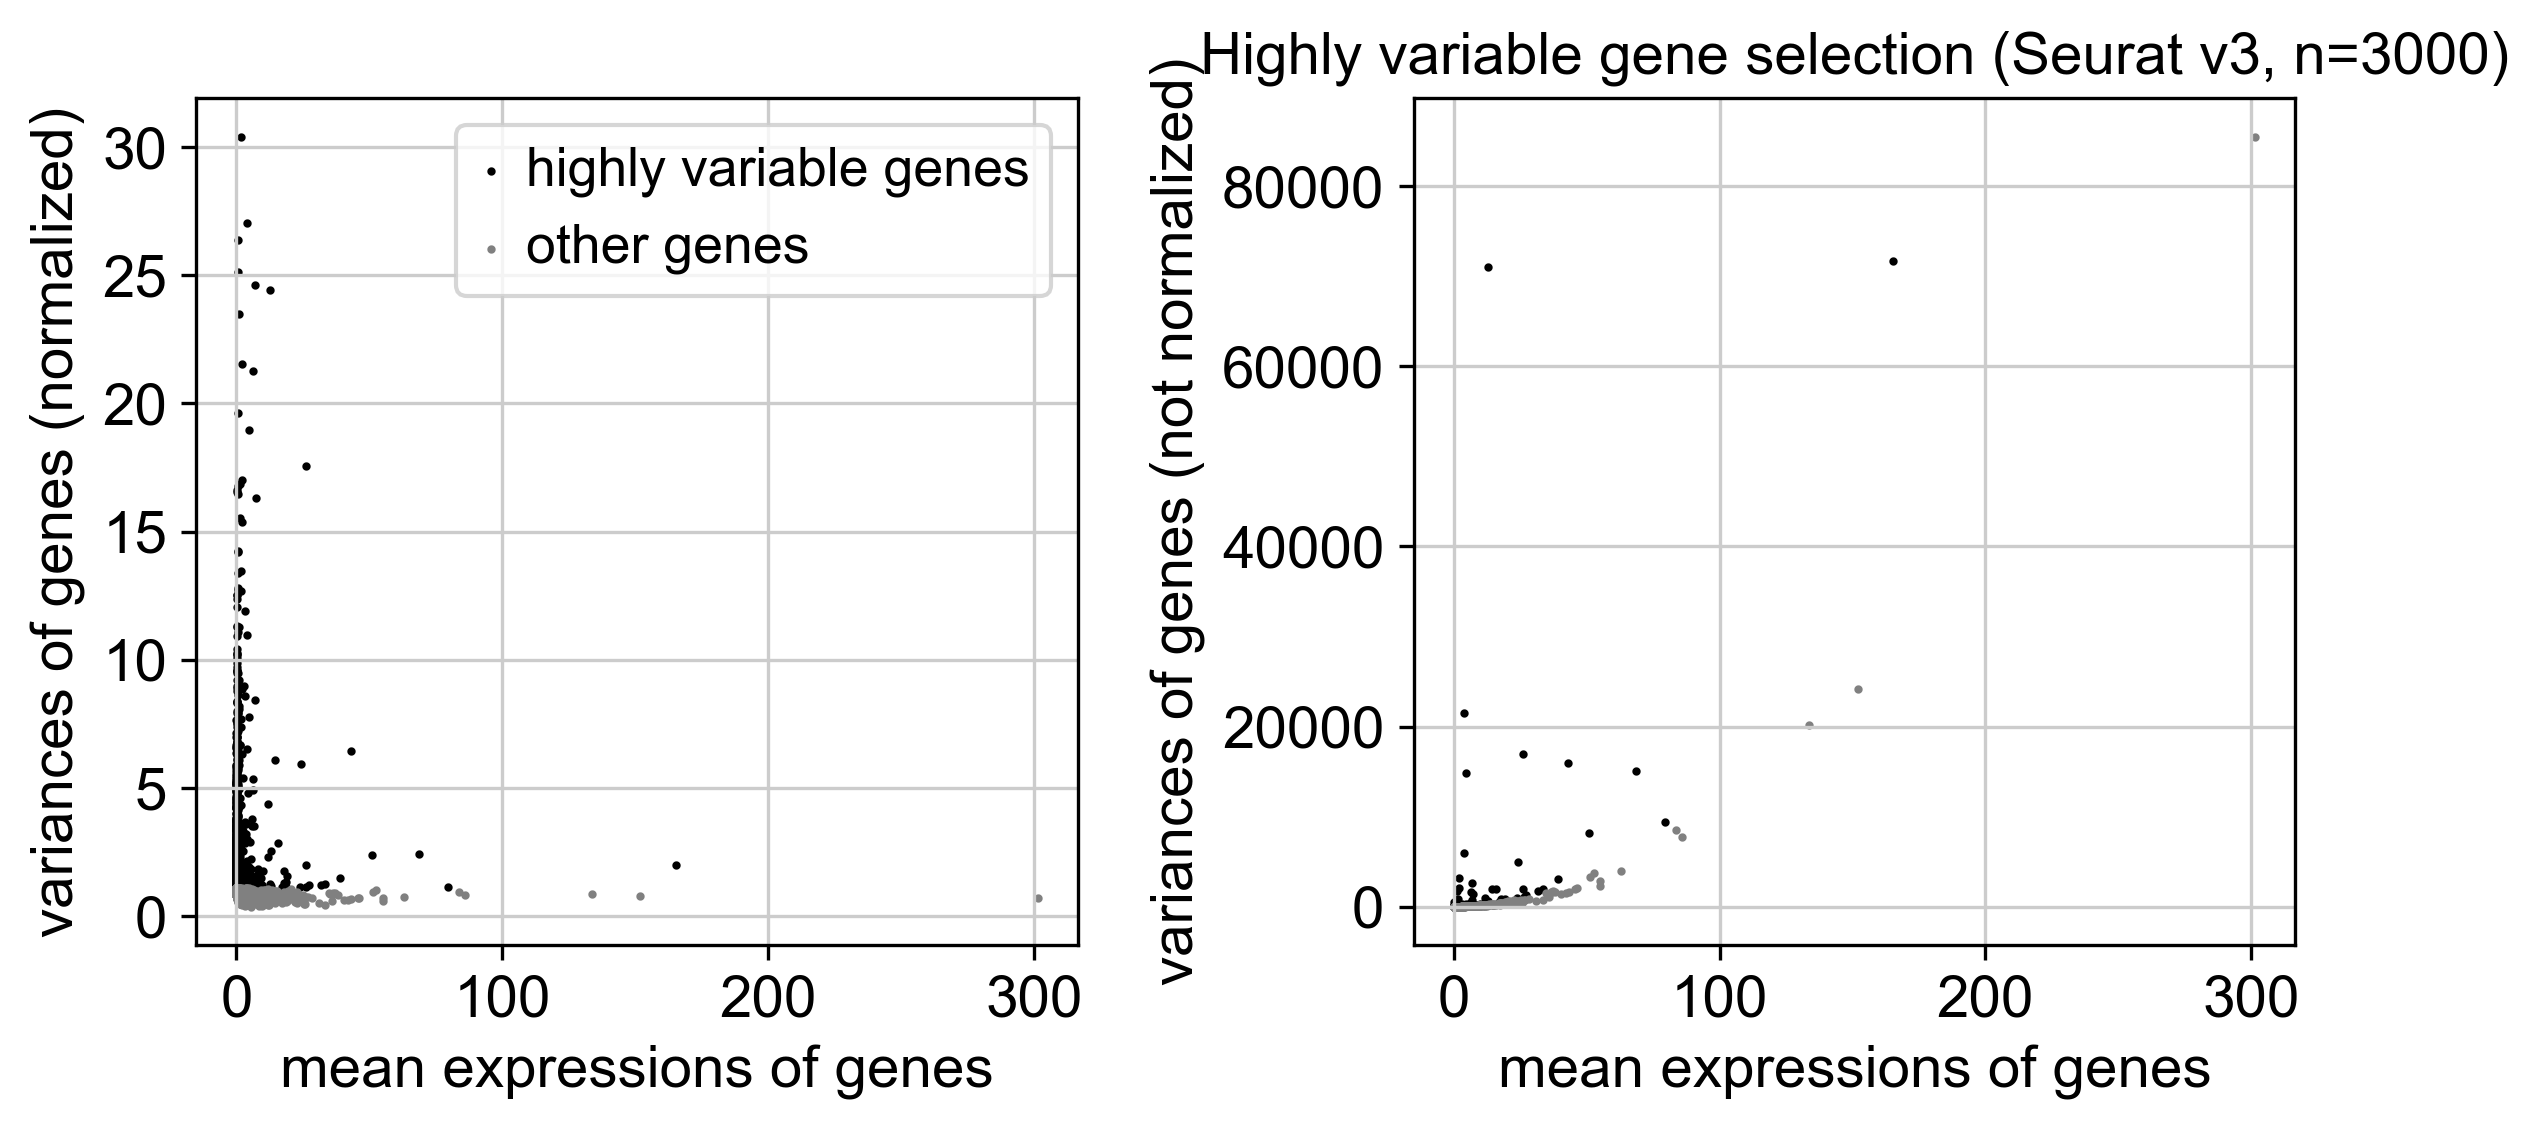

In [8]:
# Plot HVG: mean expression vs normalised variance
# HVGs are highlighted; non-HVGs are greyed out
sc.pl.highly_variable_genes(adata, show=False)
plt.title('Highly variable gene selection (Seurat v3, n=3000)')
plt.tight_layout()
plt.savefig('figures/v2/03_hvg_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Show top 20 HVGs by variance rank
hvg_table = adata.var[adata.var['highly_variable']].sort_values(
    'highly_variable_rank'
).head(20)[['highly_variable_rank', 'means', 'variances', 'variances_norm']]

print("Top 20 highly variable genes:")
print(hvg_table.to_string())

Top 20 highly variable genes:
        highly_variable_rank      means     variances  variances_norm
CHGA                     0.0   1.727891    795.732879       30.412996
PYY                      1.0   3.831472   5944.518321       27.032094
TPSB2                    2.0   0.711975    170.370946       26.372155
TPSAB1                   3.0   0.446669     59.899049       25.147565
GUCA2B                   4.0   6.897189   2682.044499       24.629915
IGKC                     5.0  12.755744  70969.969985       24.445476
GCG                      6.0   0.857656    269.386283       23.501253
IGJ                      7.0   2.022719   2044.330293       21.547641
ITLN1                    8.0   6.353356   1579.308371       21.252674
PCSK1N                   9.0   0.524965     22.500757       19.639693
IGHA1                   10.0   4.629059  14851.070344       18.964596
ZG16                    11.0  26.223463  16927.214114       17.572295
REG4                    12.0   2.058016    177.283668       

## Step 5 — Save full gene set to `adata.raw`

Before subsetting to HVGs, we save the full log-normalised matrix to `adata.raw`.
This is used later in notebook 05 for visualising marker gene expression on UMAP,
even for genes that were not selected as HVGs.
Scanpy's plotting functions automatically fall back to `adata.raw` when a gene is
absent from the main `adata.X`.

In [10]:
adata.raw = adata
print(f"adata.raw saved: {adata.raw.shape[0]:,} cells × {adata.raw.shape[1]:,} genes")

adata.raw saved: 7,791 cells × 21,970 genes


## Step 6 — Subset to HVGs

Reducing the gene space to 3,000 HVGs before PCA:
- Speeds up PCA (matrix is ~6× smaller)
- Removes uninformative genes that add noise to the PCA space
- Reduces memory footprint for scaling (full-matrix scaling on 58k genes uses excessive RAM)

In [11]:
adata = adata[:, adata.var['highly_variable']].copy()
print(f"After HVG subset: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(f"adata.raw still available: {adata.raw is not None}")

After HVG subset: 7,791 cells × 3,000 genes
adata.raw still available: True


## Step 7 — Z-score scaling

Each gene is centred to mean=0 and scaled to unit variance (Z-score).
`max_value=10` clips extreme outliers — without this, a single highly expressed gene
in a few cells can dominate the first PC, masking biological structure.

**Note**: scaling is applied to log-normalised values, not raw counts. After this step
`.X` is no longer sparse (dense float32). The `layers['counts']` layer still holds
the original raw integers.

In [12]:
sc.pp.scale(adata, max_value=10)

print(f"Post-scale dtype : {adata.X.dtype}")
print(f"Post-scale .X range: [{adata.X.min():.2f}, {adata.X.max():.2f}]")
print(f"(Max should be 10.0 due to clipping)")
print(f"layers['counts'] still intact: {adata.layers['counts'].dtype}")

Post-scale dtype : float32
Post-scale .X range: [-3.45, 10.00]
(Max should be 10.0 due to clipping)
layers['counts'] still intact: int32


## Save preprocessed AnnData

In [13]:
out_path = 'data/processed/v2/GSE116222_v2_preprocessed.h5ad'
adata.write_h5ad(out_path)
print(f"Saved : {out_path}")
print(f"Size  : {os.path.getsize(out_path) / 1e6:.1f} MB")
print(f"Shape : {adata.n_obs:,} cells × {adata.n_vars:,} genes (HVGs only)")
print(f"\n{adata}")

Saved : data/processed/v2/GSE116222_v2_preprocessed.h5ad
Size  : 230.5 MB
Shape : 7,791 cells × 3,000 genes (HVGs only)

AnnData object with n_obs × n_vars = 7791 × 3000
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'log1p_total_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_mean_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'condition_colors', 'sample_colors', 'log1p', 'hvg'
    layers: 'counts'
